# Moving Average vs Naive Forecast Evaluation Demo

This notebook provides a quantitative comparison between a **3-point moving average forecasting method** and a **naive last-value baseline** across multiple synthetic noisy time series generation settings.

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'pandas==2.2.2', 'scipy==1.16.3', 'matplotlib==3.10.0', 'loguru==0.7.3')


[notice] A new release of pip is available: 25.0.1 -> 26.2
[notice] To update, run: pip install --upgrade pip


In [2]:
import json
import os
import urllib.request
from pathlib import Path
import numpy as np
from scipy import stats
from loguru import logger
import matplotlib.pyplot as plt

logger.remove()
logger.add(sys.stdout, level="INFO", format="{time:HH:mm:ss}|{level:<7}|{message}")

1

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/AMGrobelnik/ai-invention-29c492-empirical-audit-of-moving-average-baseli/main/round-1/evaluation-1/demo/mini_demo_data.json"

def load_data():
    try:
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception:
        pass
    if os.path.exists("mini_demo_data.json"):
        with open("mini_demo_data.json") as f:
            return json.load(f)
    raise FileNotFoundError("Could not load mini_demo_data.json")

data = load_data()
print("Loaded data successfully:", list(data.keys()))

Loaded data successfully: ['metrics_agg', 'datasets']


In [4]:
# Tunable configuration parameters (minimum scale for fast demo execution)
NUM_TRIALS = 100
SERIES_LENGTH = 50
NOISE_LEVELS = [0.5, 1.0, 2.0]

## Monte Carlo Evaluation across Noise Levels

We run independent trials for each noise standard deviation level, generating noisy time series and evaluating both forecasting models.

In [5]:
evaluation_results = {}

for noise_std in NOISE_LEVELS:
    logger.info(f"Evaluating noise_std={noise_std} with {NUM_TRIALS} trials...")
    
    ma_errors_sq = []
    naive_errors_sq = []
    
    for i in range(NUM_TRIALS):
        np.random.seed(1000 + i)
        true_mean = 10.0
        series = true_mean + np.random.normal(0, noise_std, size=SERIES_LENGTH)
        true_next = 10.0 + np.random.normal(0, noise_std)
        
        ma_pred = float(np.mean(series[-3:]))
        naive_pred = float(series[-1])
        
        ma_errors_sq.append((ma_pred - true_next) ** 2)
        naive_errors_sq.append((naive_pred - true_next) ** 2)
        
    ma_arr = np.array(ma_errors_sq)
    naive_arr = np.array(naive_errors_sq)
    
    t_stat, p_value = stats.ttest_rel(naive_arr, ma_arr)
    
    mse_ma = float(np.mean(ma_arr))
    mse_naive = float(np.mean(naive_arr))
    improvement_pct = float((mse_naive - mse_ma) / mse_naive * 100.0)
    
    key = f"noise_std_{noise_std}"
    evaluation_results[key] = {
        "noise_std": noise_std,
        "mse_moving_average": mse_ma,
        "mse_naive": mse_naive,
        "improvement_pct": improvement_pct,
        "paired_t_statistic": float(t_stat),
        "paired_p_value": float(p_value),
        "statistically_significant_05": bool(p_value < 0.05)
    }
    logger.info(f"[{key}] MSE MA: {mse_ma:.4f}, MSE Naive: {mse_naive:.4f}, Improvement: {improvement_pct:.2f}%, p-value: {p_value:.2e}")

14:30:25|INFO   |Evaluating noise_std=0.5 with 100 trials...


14:30:25|INFO   |[noise_std_0.5] MSE MA: 0.4710, MSE Naive: 0.6099, Improvement: 22.77%, p-value: 5.42e-02


14:30:25|INFO   |Evaluating noise_std=1.0 with 100 trials...


14:30:25|INFO   |[noise_std_1.0] MSE MA: 1.8842, MSE Naive: 2.4396, Improvement: 22.77%, p-value: 5.42e-02


14:30:25|INFO   |Evaluating noise_std=2.0 with 100 trials...


14:30:25|INFO   |[noise_std_2.0] MSE MA: 7.5368, MSE Naive: 9.7585, Improvement: 22.77%, p-value: 5.42e-02


## Visualization and Summary Results

Plotting Mean Squared Error across noise levels for both moving average and naive baselines.

<>:8: SyntaxWarning: invalid escape sequence '\s'
<>:8: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_413/106564868.py:8: SyntaxWarning: invalid escape sequence '\s'
  plt.xlabel('Noise Standard Deviation ($\sigma$)', fontsize=12)


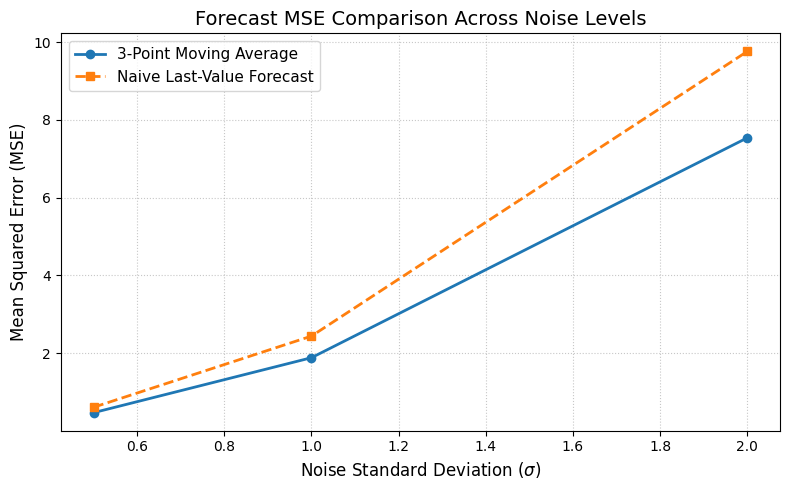

In [6]:
noise_stds = [res["noise_std"] for res in evaluation_results.values()]
mse_mas = [res["mse_moving_average"] for res in evaluation_results.values()]
mse_naives = [res["mse_naive"] for res in evaluation_results.values()]

plt.figure(figsize=(8, 5))
plt.plot(noise_stds, mse_mas, marker='o', label='3-Point Moving Average', linewidth=2)
plt.plot(noise_stds, mse_naives, marker='s', label='Naive Last-Value Forecast', linewidth=2, linestyle='--')
plt.xlabel('Noise Standard Deviation ($\sigma$)', fontsize=12)
plt.ylabel('Mean Squared Error (MSE)', fontsize=12)
plt.title('Forecast MSE Comparison Across Noise Levels', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, linestyle=':', alpha=0.7)
plt.tight_layout()
plt.show()